#UTR Diversity

Analyze alternative TSS/TTS usage across cell types. Requires loading full classification files for diff_to_TSS, diff_to_TTS, polyA_motif, and CAGE peak columns not stored in the h5ad (recollapsed data).

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from add_classification import add_classification

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

#1. Load classification files and merge with h5ad var

In [3]:
# Classification data (TSS/TTS/polyA/CAGE columns) is loaded from the combined
# SQANTI3 CSV via add_classification() in the next cell.
print("Classification will be loaded from SQANTI3 CSV in the next cell.")

Classification will be loaded from SQANTI3 CSV in the next cell.


In [4]:
# Load h5ad and merge classification
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad")
from add_classification import add_classification
add_classification(adata, "./../csvs/all_samples_recollapsed_pigeon_classification.csv",
                   isoform_col="molecule_id", prefix="pigeon_", sep=",")
print(f"Loaded: {adata.shape}")


if "tissue" not in adata.obs.columns:
    parts = adata.obs.index.str.split("_")
    adata.obs["tissue"] = ["_".join(p[1:]) if len(p) > 1 else "unknown" for p in parts]


# Load SQANTI3 classification with UTR-related columns
utr_cols = [
    "structural_category", "associated_gene", "associated_transcript",
    "diff_to_TSS", "diff_to_TTS", "diff_to_gene_TSS", "diff_to_gene_TTS",
    "polyA_motif", "polyA_dist", "polyA_motif_found",
    "dist_to_CAGE_peak", "within_CAGE_peak",
    "dist_to_polyA_site", "within_polyA_site",
    "ratio_TSS",
]
add_classification(adata, "./../csvs/all_samples_recollapsed_sqanti3_classification.csv",
                   columns=utr_cols, isoform_col="molecule_id", prefix="sqanti_", sep=",")

# Convert numeric columns
for col in ["sqanti_diff_to_TSS", "sqanti_diff_to_TTS", "sqanti_diff_to_gene_TSS", "sqanti_diff_to_gene_TTS",
            "sqanti_polyA_dist", "sqanti_dist_to_CAGE_peak", "sqanti_dist_to_polyA_site", "sqanti_ratio_TSS"]:
    if col in adata.var.columns:
        adata.var[col] = pd.to_numeric(adata.var[col], errors="coerce")

n_tss = adata.var["sqanti_diff_to_TSS"].notna().sum()
print(f"Isoforms with TSS/TTS annotations: {n_tss} / {adata.n_vars}")
gc.collect()

Columns not found in classification file: {'filter_result'}


Loaded: (203311, 854410)
Isoforms with TSS/TTS annotations: 504838 / 854410


47

#2. TSS and TTS offset distributions for FSM/ISM isoforms

In [5]:
import os
os.makedirs("figures", exist_ok=True)
known_cats = {"full-splice_match", "incomplete-splice_match"}
if "pigeon_structural_category" in adata.var.columns:
    known_mask = adata.var["pigeon_structural_category"].isin(known_cats)
else:
    known_mask = pd.Series(True, index=adata.var.index)

# TSS offsets
tss_diffs = None
if "sqanti_diff_to_TSS" in adata.var.columns:
    tss_diffs = adata.var.loc[known_mask, "sqanti_diff_to_TSS"].dropna()
    tss_diffs = tss_diffs[(tss_diffs.abs() <= 500)]  # clip for visibility

# TTS offsets
tts_diffs = None
if "sqanti_diff_to_TTS" in adata.var.columns:
    tts_diffs = adata.var.loc[known_mask, "sqanti_diff_to_TTS"].dropna()
    tts_diffs = tts_diffs[(tts_diffs.abs() <= 500)]


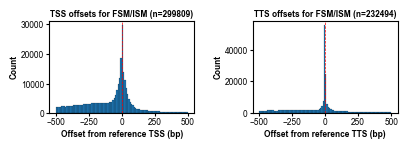

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(4.5, 1.2))

if tss_diffs is not None:
    axes[0].hist(tss_diffs, bins=100, edgecolor="black", linewidth=0.1)
    axes[0].set_xlabel("Offset from reference TSS (bp)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"TSS offsets for FSM/ISM (n={len(tss_diffs)})")
    axes[0].axvline(0, color="red", linestyle="--", linewidth=0.5)

if tts_diffs is not None:
    axes[1].hist(tts_diffs, bins=100, edgecolor="black", linewidth=0.1)
    axes[1].set_xlabel("Offset from reference TTS (bp)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"TTS offsets for FSM/ISM (n={len(tts_diffs)})")
    axes[1].axvline(0, color="red", linestyle="--", linewidth=0.5)

plt.subplots_adjust(wspace = 0.4)
plt.savefig(figpath("03_04_TSS_TTS_offsets.pdf"))   # PAPER: TSS/TTS offset distributions
plt.show()

#3. Per-gene TSS diversity

In [7]:
# Per-gene TSS diversity (Supp Fig 4F).
#
# Three corrections over the previous version.
#
# 1. GENE COLUMN. It grouped by `pigeon_associated_gene`, which has 39,305 distinct values --
#    but 1,835 of those are `novelGene_*` placeholders and 220 are fusion `ENSGx_ENSGy` IDs,
#    neither of which is a gene in the sense used everywhere else in the manuscript. The atlas
#    gene count is `gene_name`: 37,805. Reporting 39,305 here contradicted the paper's own
#    gene number by 1,500. Group by gene_name; both counts are printed so the gap stays visible.
#
# 2. TSS REFERENCE COLUMN. It used sqanti_diff_to_gene_TSS if present and silently fell back to
#    sqanti_diff_to_TSS. Those are not interchangeable: the first is the offset to the GENE's
#    annotated TSS, so bins are comparable across a gene's isoforms; the second is the offset to
#    each isoform's own matched reference transcript, so two isoforms in the same bin need not
#    share a genomic position and "distinct TSS" would be meaningless. Require the gene-level
#    column and say which one was used.
#
# 3. BIN WIDTH IS PART OF THE MEASUREMENT. Positions are binned before counting, so "distinct
#    TSS per gene" is really "distinct TSS bins", and the value scales with the bin: halve
#    TSS_BIN_BP and it rises. It is named and printed here, and stated on the axis in the plot
#    cell, so the number is never quoted as a bin-free property of the data.
TSS_BIN_BP = 50          # resolution at which two start sites count as distinct

gene_col = "gene_name"
if gene_col not in adata.var.columns:
    raise KeyError("gene_name not in adata.var -- needed so the gene count matches the atlas")

if "sqanti_diff_to_gene_TSS" in adata.var.columns:
    tss_col = "sqanti_diff_to_gene_TSS"
else:
    raise KeyError(
        "sqanti_diff_to_gene_TSS not found. Do NOT substitute sqanti_diff_to_TSS: it is measured "
        "against each isoform's own reference transcript, so bins are not comparable within a "
        "gene. Re-run add_classification() to attach the gene-level column.")

_v = adata.var.dropna(subset=[tss_col, gene_col]).copy()
_v["tss_bin"] = (_v[tss_col] / TSS_BIN_BP).round()
gene_tss_diversity = _v.groupby(gene_col, observed=True)["tss_bin"].nunique()
gene_tss_diversity.name = "n_tss_positions"

# structures per gene: the count above cannot exceed it, so report it as the ceiling that
# makes this partly a measure of detection depth rather than of promoter usage alone.
structs_per_gene = _v.groupby(gene_col, observed=True).size()

print(f"TSS column          : {tss_col}")
print(f"gene column         : {gene_col}  ({adata.var[gene_col].nunique():,} genes in .var)")
print(f"  for comparison, pigeon_associated_gene has "
      f"{adata.var['pigeon_associated_gene'].nunique():,} values incl. novelGene_*/fusion IDs")
print(f"bin width           : {TSS_BIN_BP} bp")
print(f"transcript structures used: {len(_v):,} of {adata.n_vars:,}")
print()
print(f"Genes with TSS info : {len(gene_tss_diversity):,}")
print(f"Mean distinct TSS bins per gene: {gene_tss_diversity.mean():.2f} "
      f"(median {gene_tss_diversity.median():.0f})")
_ge3 = int((gene_tss_diversity >= 3).sum())
print(f"Genes with >= 3 distinct TSS bins: {_ge3:,} ({_ge3/len(gene_tss_diversity):.1%})")
print(f"Structures per gene : mean {structs_per_gene.mean():.1f}, median "
      f"{structs_per_gene.median():.0f}  <- upper bound on the count above")

# Sensitivity: the mean mixes genes with one detected structure (which contribute exactly 1 by
# construction) with deeply covered genes. Report the same statistic on better-covered genes so
# the depth dependence is quantified rather than argued about.
for _min in (3, 5, 10):
    _sel = gene_tss_diversity[structs_per_gene >= _min]
    if len(_sel):
        print(f"  genes with >= {_min:>2} structures (n={len(_sel):,}): "
              f"mean {_sel.mean():.2f} distinct TSS bins, "
              f">=3 bins in {(_sel >= 3).mean():.1%}")

# Bin-width sensitivity: quote alongside the headline, since the headline depends on it.
for _bw in (25, 100):
    _b = (_v[tss_col] / _bw).round()
    _alt = _b.groupby(_v[gene_col], observed=True).nunique()
    print(f"  at {_bw:>3} bp bins: mean {_alt.mean():.2f} distinct TSS bins per gene")


TSS column          : sqanti_diff_to_gene_TSS
gene column         : gene_name  (37,805 genes in .var)
  for comparison, pigeon_associated_gene has 39,478 values incl. novelGene_*/fusion IDs
bin width           : 50 bp
transcript structures used: 854,261 of 854,410

Genes with TSS info : 37,799
Mean distinct TSS bins per gene: 8.89 (median 4)
Genes with >= 3 distinct TSS bins: 22,706 (60.1%)
Structures per gene : mean 22.6, median 6  <- upper bound on the count above
  genes with >=  3 structures (n=25,683): mean 12.47 distinct TSS bins, >=3 bins in 88.4%
  genes with >=  5 structures (n=20,890): mean 14.71 distinct TSS bins, >=3 bins in 94.5%
  genes with >= 10 structures (n=16,011): mean 17.94 distinct TSS bins, >=3 bins in 98.4%
  at  25 bp bins: mean 10.57 distinct TSS bins per gene
  at 100 bp bins: mean 7.37 distinct TSS bins per gene


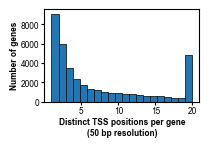

In [8]:
if gene_tss_diversity is not None:
    fig, ax = plt.subplots(figsize=(2, 1.2))
    ax.hist(gene_tss_diversity.clip(upper=20), bins=20, edgecolor="black", linewidth=0.5)
    # Axis states the bin width: the count is a function of it, so a bare "distinct TSS" label
    # would overstate what is measured.
    ax.set_xlabel(f"Distinct TSS positions per gene\n({TSS_BIN_BP} bp resolution)")
    ax.set_ylabel("Number of genes")
    plt.savefig(figpath("03_04_per_gene_TSS_diversity.pdf"))   # PAPER: per-gene TSS diversity
    plt.show()


#4. Cell-type-specific TSS/TTS usage

In [9]:
# For genes with multiple TSS, check if different cell types prefer different start sites
cell_types = sorted([ct for ct in adata.obs["cell_ontology_class"].unique() if ct != "unknown"])
ct_sizes = adata.obs["cell_ontology_class"].value_counts()
large_cts = [ct for ct in cell_types if ct_sizes.get(ct, 0) >= 100][:15]  # top 15

if tss_col:
    multi_tss_genes = gene_tss_diversity[gene_tss_diversity >= 3].index.tolist()
    print(f"Analyzing {len(multi_tss_genes)} genes with >= 3 TSS across {len(large_cts)} cell types")

    # For each gene, compute mean TSS offset per cell type (weighted by expression)
    genes_var = adata.var[gene_col].values
    gene_to_cols = {}
    for idx, g in enumerate(genes_var):
        gene_to_cols.setdefault(g, []).append(idx)

    tss_vals = adata.var[tss_col].values

    # Compute mean TSS per cell type for top variable genes
    tss_var_records = []
    for gene in multi_tss_genes[:200]:  # limit for performance
        cols = gene_to_cols.get(gene, [])
        if len(cols) < 2:
            continue
        gene_tss = tss_vals[cols]
        if np.all(np.isnan(gene_tss.astype(float))):
            continue

        ct_mean_tss = []
        for ct in large_cts:
            ct_mask = (adata.obs["cell_ontology_class"] == ct).values
            if ct_mask.sum() < 20:
                continue
            expr = np.array(adata.X[ct_mask][:, cols].mean(axis=0)).ravel()
            total_expr = expr.sum()
            if total_expr > 0:
                gene_tss_float = np.array(gene_tss, dtype=float)
                valid = ~np.isnan(gene_tss_float)
                if valid.any():
                    weighted_tss = np.nansum(expr[valid] * gene_tss_float[valid]) / expr[valid].sum()
                    ct_mean_tss.append(weighted_tss)

        if len(ct_mean_tss) >= 3:
            tss_var_records.append({"gene": gene, "tss_var": np.var(ct_mean_tss),
                                    "tss_range": max(ct_mean_tss) - min(ct_mean_tss)})

    tss_var_df = pd.DataFrame(tss_var_records).sort_values("tss_var", ascending=False)
    print(f"\nTop genes with cell-type-variable TSS usage:")
    print(tss_var_df.head(20).to_string(index=False))

Analyzing 22706 genes with >= 3 TSS across 15 cell types

Top genes with cell-type-variable TSS usage:
   gene      tss_var    tss_range
  ABTB2 1.226520e+09 88165.000000
  ABCG2 2.907382e+08 66605.333483
ABHD17C 2.714191e+08 44965.000000
 ABHD18 2.127007e+08 42281.883212
  ACSM1 1.861628e+08 45029.000000
   ABI1 1.489245e+08 51506.909706
  ACOXL 1.462841e+08 32286.332215
  ACSS3 1.453286e+08 35741.211718
  ABCD2 1.358044e+08 33631.200000
  ABHD2 1.320942e+08 50999.000000
   ACO1 1.279898e+08 39600.424922
   ABL1 1.206368e+08 41946.666667
AADACP1 1.015271e+08 37530.000000
  AADAT 9.280695e+07 25229.000000
 ABCC11 7.522589e+07 19767.000000
  ABCA1 6.148159e+07 28285.791667
ABHD17B 5.253028e+07 24004.000000
  ABCC4 4.609253e+07 27094.000000
  ABCB1 3.077040e+07 23528.000000
  AASDH 2.865472e+07 19036.250000



Top genes with cell-type-variable TSS usage:
                                 gene      tss_var    tss_range
                   ENSG00000007174.18 1.083641e+09 77781.000000
                   ENSG00000005108.17 9.382657e+08 96762.329792
                   ENSG00000000460.17 3.059267e+08 53847.000000
                   ENSG00000005249.13 1.857195e+08 49048.666672
                   ENSG00000001626.18 1.144529e+08 36217.000000
                   ENSG00000000457.14 8.241788e+07 33982.166667
                   ENSG00000003096.15 7.540680e+07 28072.000000
                   ENSG00000007062.12 7.225563e+07 25647.750000
                   ENSG00000007866.22 4.089381e+07 21444.000000
                   ENSG00000004809.14 4.038881e+07 15659.125000
                   ENSG00000006704.11 3.674981e+07 24145.500000
                   ENSG00000003147.19 3.014614e+07 16045.994104
ENSG00000005075.16_ENSG00000170667.15 2.144255e+07  9980.999840
                   ENSG00000007216.16 2.051968e+07 12574.5

#5. Tissue-specific TSS/TTS patterns

In [10]:
tissues = sorted(adata.obs["tissue"].unique())

tss_series = None
if tss_col:
    # Mean TSS offset per tissue
    tissue_mean_tss = {}
    for tissue in tissues:
        t_mask = (adata.obs["tissue"] == tissue).values
        if t_mask.sum() < 10:
            continue
        # Weighted mean TSS across all isoforms
        expr = np.array(adata.X[t_mask].mean(axis=0)).ravel()
        tss_float = adata.var[tss_col].astype(float).values
        valid = ~np.isnan(tss_float) & (expr > 0)
        if valid.sum() > 0:
            tissue_mean_tss[tissue] = np.average(tss_float[valid], weights=expr[valid])

    tss_series = pd.Series(tissue_mean_tss).sort_values()


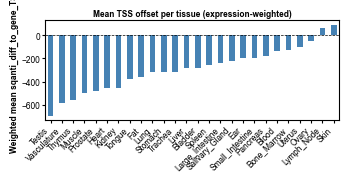

In [11]:
if tss_series is not None:
    fig, ax = plt.subplots(figsize=(3.8, 1.3))
    tss_series.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_ylabel(f"Weighted mean {tss_col}")
    ax.set_title("Mean TSS offset per tissue (expression-weighted)")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    plt.xticks(rotation=45, ha="right")
    plt.savefig(figpath("03_04_TSS_offset_per_tissue.pdf"))   # PAPER: tissue-specific TSS offset
    plt.show()


#6. TSS diversity and gene function

In [12]:
if tss_col:
    # Genes with highest TSS diversity
    high_tss_genes = gene_tss_diversity.nlargest(100).index.tolist()
    print(f"Top 50 genes by TSS diversity:")
    print(", ".join(high_tss_genes[:50]))

    # Save for external analysis
    pd.Series(high_tss_genes, name="high_tss_diversity_genes").to_csv(
        "./../csvs/high_tss_diversity_genes.csv", index=False
    )
    print("\nSaved to high_tss_diversity_genes.csv for GO/pathway enrichment")

Top 50 genes by TSS diversity:
TTN, SYNE1, SYNE2, DST, UTRN, NBPF19, NBPF10, MACF1, LAMA2, ANKRD36C, NBPF14, VPS13C, BIRC6, NBPF20, LRP1, MYCBP2, AKAP9, PRKDC, FBN1, HUWE1, SPTBN1, USP34, DYNC1H1, HERC1, ANKRD36, NIPBL, ITPR2, BAZ2B, KIAA1109, DYNC2H1, LRRK2, SMG1, TPR, UBR5, UBR4, CEP290, VPS13A, AKAP13, COL12A1, ECPAS, MYOF, MDN1, PTPN13, PCM1, USP9X, PSME4, RNF213, CHD1, COL6A3, LYST

Saved to high_tss_diversity_genes.csv for GO/pathway enrichment


#7. Alternative polyadenylation

In [13]:
pa_motifs = None
pa_dist = None
if "sqanti_polyA_motif" in adata.var.columns:
    pa_motifs = adata.var["sqanti_polyA_motif"].dropna()
    print(f"Isoforms with polyA motif annotation: {len(pa_motifs)} / {adata.n_vars}")
    print(f"\nPolyA motif distribution:")
    print(pa_motifs.value_counts().head(10))

    if "sqanti_polyA_dist" in adata.var.columns:
        pa_dist = adata.var["sqanti_polyA_dist"].dropna()
        pa_dist = pa_dist[(pa_dist.abs() <= 100)]
else:
    print("polyA_motif column not found")

if "sqanti_polyA_motif_found" in adata.var.columns:
    pa_found = adata.var["sqanti_polyA_motif_found"].value_counts()
    print(f"\nPolyA motif found:")
    print(pa_found)

polya_by_cat = None
polya_true_col = None
if "sqanti_within_polyA_site" in adata.var.columns:
    pa_site = adata.var["sqanti_within_polyA_site"].value_counts()
    print(f"\nWithin known polyA site:")
    print(pa_site)

    # PAPER: novel-TTS validation — fraction within a known polyA site by structural category
    # (mirror of the CAGE/TSS validation in section 8)
    if "pigeon_structural_category" in adata.var.columns:
        polya_by_cat = pd.crosstab(adata.var["pigeon_structural_category"],
                                    adata.var["sqanti_within_polyA_site"], normalize="index")
        print("\nFraction within polyA site by structural category:")
        print(polya_by_cat)
        # within_polyA_site is stored as strings "True"/"False"; pick whichever representation is present
        polya_true_col = next((_v for _v in ["TRUE", "True", True, "true"] if _v in polya_by_cat.columns), None)


Isoforms with polyA motif annotation: 561436 / 854410

PolyA motif distribution:
sqanti_polyA_motif
AATAAA    275390
ATTAAA     77168
AAGAAA     25921
AGTAAA     22116
AAAAAG     21396
TATAAA     21214
TTTAAA     18068
GATAAA     13922
AATGAA     13898
AATATA     13067
Name: count, dtype: int64

PolyA motif found:
sqanti_polyA_motif_found
True     561436
False    292974
Name: count, dtype: int64

Within known polyA site:
sqanti_within_polyA_site
False    765404
True      89006
Name: count, dtype: int64

Fraction within polyA site by structural category:
sqanti_within_polyA_site       False      True
pigeon_structural_category                    
antisense                   0.983108  0.016892
full-splice_match           0.878962  0.121038
fusion                      0.897189  0.102811
genic                       0.926490  0.073510
incomplete-splice_match     0.934989  0.065011
intergenic                  0.993675  0.006325
moreJunctions               0.873418  0.126582
novel_in_catalog 

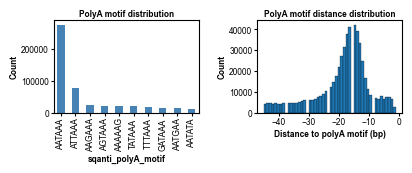

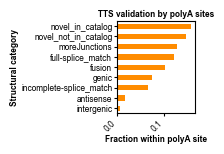

In [14]:
if pa_motifs is not None:
    fig, axes = plt.subplots(1, 2, figsize=(4.5, 1.2))
    pa_motifs.value_counts().head(10).plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_ylabel("Count")
    axes[0].set_title("PolyA motif distribution")
    if pa_dist is not None:
        axes[1].hist(pa_dist, bins=50, edgecolor="black", linewidth=0.2)
        axes[1].set_xlabel("Distance to polyA motif (bp)")
        axes[1].set_ylabel("Count")
        axes[1].set_title("PolyA motif distance distribution")
    plt.subplots_adjust(wspace = 0.4)
    plt.savefig(figpath("03_04_polyA_motif.pdf"))   # PAPER: polyadenylation motifs
    plt.show()

if polya_by_cat is not None and polya_true_col is not None:
    fig, ax = plt.subplots(figsize=(1.0, 1.2))
    if polya_true_col in polya_by_cat.columns:
        polya_by_cat[polya_true_col].sort_values(ascending=True).plot(kind="barh", ax=ax, color="darkorange")
    ax.set_xlabel("Fraction within polyA site")
    ax.set_ylabel("Structural category")
    ax.set_title("TTS validation by polyA sites")
    plt.xticks(rotation=45, ha="right")
    plt.savefig(figpath("03_04_novel_TTS_polyA_support.pdf"))   # PAPER: novel TTS polyA support
    plt.show()

#8. CAGE peak validation

In [15]:
cage_by_cat = None
cage_true_col = None
cage_dist = None
if "sqanti_within_CAGE_peak" in adata.var.columns:
    cage_vals = adata.var["sqanti_within_CAGE_peak"].value_counts()
    print("Within CAGE peak:")
    print(cage_vals)

    # By structural category
    if "pigeon_structural_category" in adata.var.columns:
        cage_by_cat = pd.crosstab(adata.var["pigeon_structural_category"],
                                   adata.var["sqanti_within_CAGE_peak"], normalize="index")
        print("\nFraction within CAGE peak by structural category:")
        print(cage_by_cat)
        # within_CAGE_peak is stored as strings "True"/"False" (dtype=str); pick whichever
        # representation of "within CAGE peak" is actually present as a crosstab column.
        cage_true_col = next((_v for _v in ["TRUE", "True", True, "true"] if _v in cage_by_cat.columns), None)

    if "sqanti_dist_to_CAGE_peak" in adata.var.columns:
        cage_dist = adata.var["sqanti_dist_to_CAGE_peak"].dropna()
        cage_dist = cage_dist[(cage_dist.abs() <= 500)]
else:
    print("within_CAGE_peak column not found")

Within CAGE peak:
sqanti_within_CAGE_peak
False    528212
True     326198
Name: count, dtype: int64

Fraction within CAGE peak by structural category:
sqanti_within_CAGE_peak        False      True
pigeon_structural_category                    
antisense                   0.959459  0.040541
full-splice_match           0.559329  0.440671
fusion                      0.539497  0.460503
genic                       0.688935  0.311065
incomplete-splice_match     0.756204  0.243796
intergenic                  0.944796  0.055204
moreJunctions               0.506329  0.493671
novel_in_catalog            0.399465  0.600535
novel_not_in_catalog        0.491779  0.508221


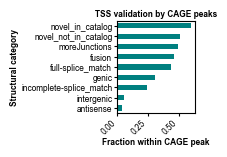

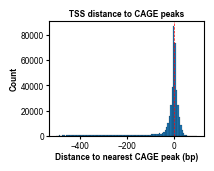

In [16]:
if cage_by_cat is not None:
    fig, ax = plt.subplots(figsize=(1.0, 1.2))
    if cage_true_col in cage_by_cat.columns:
        cage_by_cat[cage_true_col].sort_values(ascending=True).plot(kind="barh", ax=ax, color="teal")
    ax.set_xlabel("Fraction within CAGE peak")
    ax.set_ylabel("Structural category")
    ax.set_title("TSS validation by CAGE peaks")
    plt.xticks(rotation=45, ha="right")
    plt.savefig(figpath("03_04_novel_TSS_CAGE_support.pdf"))   # PAPER: novel TSS CAGE support
    plt.show()

if cage_dist is not None and len(cage_dist) > 0:
    fig, ax = plt.subplots(figsize=(2, 1.5))
    ax.hist(cage_dist, bins=100, edgecolor="black", linewidth=0.1)
    ax.set_xlabel("Distance to nearest CAGE peak (bp)")
    ax.set_ylabel("Count")
    ax.set_title("TSS distance to CAGE peaks")
    ax.axvline(0, color="red", linestyle="--", linewidth=0.5)
    plt.savefig(figpath("03_04_TSS_CAGE_distance.pdf"))   # PAPER: TSS-to-CAGE distance
    plt.show()


In [17]:
# --- Boundary-validation rates: all isoforms vs novel (NIC+NNC) isoforms ---
# These are PER-ISOFORM boundary metrics (canonical polyA motif at the 3' TTS,
# CAGE peak at the 5' TSS) - NOT splice-junction metrics. Reported over ALL isoforms
# and, separately, over just the novel (NIC + NNC) isoforms, so the denominator is explicit.
_sc = adata.var["pigeon_structural_category"].astype(str)
_masks = {
    "ALL isoforms": np.ones(adata.n_vars, dtype=bool),
    "NOVEL isoforms (NIC+NNC)": _sc.isin(["novel_in_catalog", "novel_not_in_catalog"]).values,
}

def _pct_true(mask, col):
    """% "True" among isoforms with a defined True/False call in `col`."""
    v = adata.var.loc[mask, col].astype(str).str.upper()
    d = int(v.isin(["TRUE", "FALSE"]).sum())     # isoforms with a call
    t = int((v == "TRUE").sum())
    return (100 * t / d if d else float("nan")), t, d

for _label, _m in _masks.items():
    p_pa, t_pa, d_pa = _pct_true(_m, "sqanti_polyA_motif_found")
    p_cg, t_cg, d_cg = _pct_true(_m, "sqanti_within_CAGE_peak")
    print(f"{_label} (n={int(_m.sum()):,}):")
    print(f"  canonical polyA motif at TTS : {p_pa:.1f}%  ({t_pa:,}/{d_pa:,})")
    print(f"  TSS within CAGE peak         : {p_cg:.1f}%  ({t_cg:,}/{d_cg:,})")

ALL isoforms (n=854,410):
  canonical polyA motif at TTS : 65.7%  (561,436/854,410)
  TSS within CAGE peak         : 38.2%  (326,198/854,410)
NOVEL isoforms (NIC+NNC) (n=321,443):
  canonical polyA motif at TTS : 79.8%  (256,441/321,443)
  TSS within CAGE peak         : 54.5%  (175,128/321,443)


## 9. Single-cell strength: novel-TSS usage across cell types, reproduced across donors

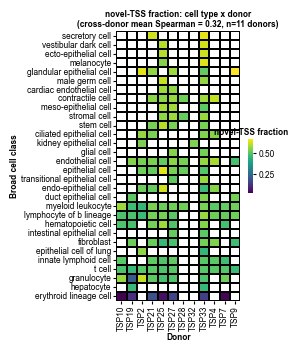

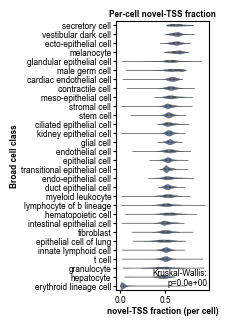

[novel-TSS] cross-donor mean pairwise Spearman = 0.319 over 11 donors x 30 broad cell classes


In [19]:
# Single-cell strength: novel-TSS usage across cell types + cross-donor reproducibility.
# Two things a bulk long-read study cannot show and that this section makes explicit:
#   (1) the PER-CELL distribution of novel-TSS usage across cell types (single-cell resolution), and
#   (2) that the cell-type pattern REPRODUCES across independent donors (multi-donor robustness).
# Efficient: two full-matrix reductions -> per-cell fractions -> cheap groupby (tractable on the
# 16.7M-isoform object). Run on a bigmem node.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr, kruskal
from itertools import combinations

if "sqanti_within_CAGE_peak" in adata.var.columns:
    _wc = adata.var["sqanti_within_CAGE_peak"].astype(str).str.upper()
    feat_mask = (_wc == "FALSE").values   # TSS NOT within a CAGE peak = novel / alternative TSS
else:
    feat_mask = None
_ok = (feat_mask is not None) and bool(feat_mask.sum() > 0)
LABEL = "novel-TSS"

if not _ok:
    print("Skipping novel-TSS single-cell/cross-donor section - required feature/column not available.")
else:
    _A = adata
    _tot  = np.asarray(_A.X.sum(axis=1)).ravel().astype(float)
    _feat = np.asarray(_A.X[:, feat_mask].sum(axis=1)).ravel().astype(float)
    _frac = np.divide(_feat, _tot, out=np.zeros_like(_feat), where=_tot > 0)

    cell_df = _A.obs[["donor", "broad_cell_class", "cell_ontology_class"]].astype(str).copy()
    cell_df["frac"] = _frac
    cell_df = cell_df[(cell_df["broad_cell_class"] != "unknown") & (_tot > 0)]

    # (A) mean fraction per (broad_cell_class x donor); keep combos with >= 20 cells
    combo = (cell_df.groupby(["broad_cell_class", "donor"], observed=True)["frac"]
                     .agg(["mean", "size"]).reset_index())
    combo = combo[combo["size"] >= 20]
    pivot = combo.pivot(index="broad_cell_class", columns="donor", values="mean")
    pivot = pivot[pivot.notna().sum(axis=1) >= 2]           # cell classes seen in >= 2 donors

    # (B) cross-donor reproducibility = mean pairwise Spearman of the cell-type profiles
    donors = [d for d in pivot.columns if pivot[d].notna().sum() >= 3]
    rhos = []
    for a, b in combinations(donors, 2):
        m = pivot[a].notna() & pivot[b].notna()
        if m.sum() >= 3:
            r, _ = spearmanr(pivot.loc[m, a], pivot.loc[m, b])
            if np.isfinite(r):
                rhos.append(r)
    mean_rho = float(np.mean(rhos)) if rhos else float("nan")
    order = pivot.mean(axis=1).sort_values(ascending=False).index.tolist()

    # preferred plot formatting
    _TICK_LEN  = globals().get("TICK_LEN", 2.0)
    _TICK_PAD  = globals().get("TICK_LABEL_PAD", 1.5)
    _TITLE_PAD = globals().get("PANEL_TITLE_PAD", 3.0)

    # ---- Figure 1: cell-type x donor heatmap (cross-donor reproducibility) ----
    fig1, ax1 = plt.subplots(figsize=(2.0, 3.5))
    sns.heatmap(pivot.loc[order], ax=ax1, cmap="viridis", linewidths=0.05, linecolor="black",
                cbar_kws={"shrink": 0.2, "aspect": 10.0})
    ax1.set_title(f"{LABEL} fraction: cell type x donor\n(cross-donor mean Spearman = {mean_rho:.2f}, n={len(donors)} donors)",
                  fontweight="bold", pad=_TITLE_PAD)
    ax1.set_xlabel("Donor", fontweight="bold")
    ax1.set_ylabel("Broad cell class", fontweight="bold")
    ax1.tick_params(length=_TICK_LEN, pad=_TICK_PAD)
    _cb = ax1.collections[0].colorbar
    _cb.ax.set_title(f"{LABEL} fraction", fontsize=6, fontweight="bold", pad=_TITLE_PAD)  # colorbar title on top
    _cb.ax.tick_params(labelsize=6, length=_TICK_LEN, pad=_TICK_PAD)
    fig1.savefig(figpath("03_04_singlecell_novelTSS_crossdonor_heatmap.pdf"), bbox_inches="tight", dpi=300)
    plt.show()

    # ---- Figure 2: per-cell violin (single-cell distribution) ----
    vdf = cell_df[cell_df["broad_cell_class"].isin(order)].copy()
    if len(vdf) > 60000:
        vdf = vdf.sample(60000, random_state=0)
    fig2, ax2 = plt.subplots(figsize=(1.2, 3.5))
    sns.violinplot(data=vdf, y="broad_cell_class", x="frac", order=order, ax=ax2,
                   inner="box", cut=0, linewidth=0.25, color="#4c72b0")
    ax2.set_title(f"Per-cell {LABEL} fraction", fontweight="bold", pad=_TITLE_PAD)
    ax2.set_xlabel(f"{LABEL} fraction (per cell)", fontweight="bold")
    ax2.set_ylabel("Broad cell class")
    ax2.tick_params(length=_TICK_LEN, pad=_TICK_PAD)

    groups = [g["frac"].values for _, g in vdf.groupby("broad_cell_class", observed=True) if len(g) >= 20]
    if len(groups) >= 2:
        H, pkw = kruskal(*groups)
        ax2.annotate(f"Kruskal-Wallis:\np={pkw:.1e}", xy=(0.98, 0.01),
                     xycoords="axes fraction", ha="right", va="bottom", fontsize=6)

    fig2.savefig(figpath("03_04_singlecell_novelTSS_crossdonor_violin.pdf"), bbox_inches="tight", dpi=300)
    plt.show()
    print(f"[{LABEL}] cross-donor mean pairwise Spearman = {mean_rho:.3f} "
          f"over {len(donors)} donors x {len(order)} broad cell classes")
